# Regression in Scikit-learn

In [81]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# others
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [82]:
# import dataset
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [83]:
df_linear=df.loc[:, ['age', 'fare']]


In [84]:
df_linear

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [85]:
# Simple linear regression
x = df[['age']]
y = df['fare']


In [86]:
df_linear.age.fillna(value=x['age'].mean(), inplace=True)

In [87]:
df_linear.isnull().sum() / len(x) * 100

age     0.0
fare    0.0
dtype: float64

In [88]:
y.isnull().sum() / len(y) * 100

np.float64(0.0)

In [89]:
y.isnull().sum()

np.int64(0)

In [90]:
x.isnull().sum()

age    177
dtype: int64

In [91]:
x.shape

(891, 1)

In [92]:
y.shape

(891,)

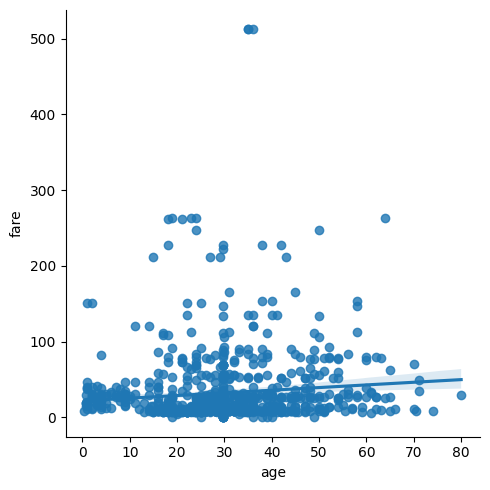

In [93]:
# Plot 
sns.lmplot(data= df_linear, x = 'age', y = 'fare')

<Axes: ylabel='age'>

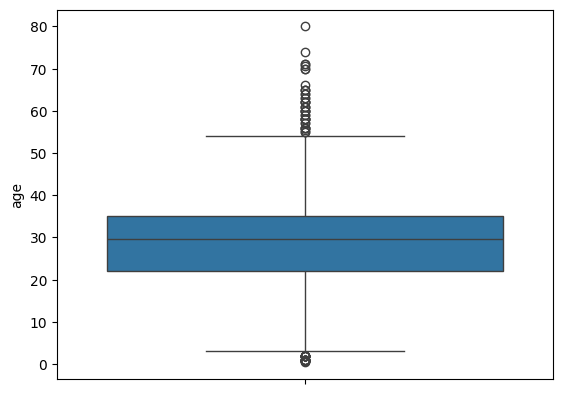

In [94]:
sns.boxplot(data = df_linear, y = 'age')

In [95]:
df_linear = df_linear[(df_linear['age'] > 8 & (df_linear['age'] < 40) )]

<Axes: ylabel='fare'>

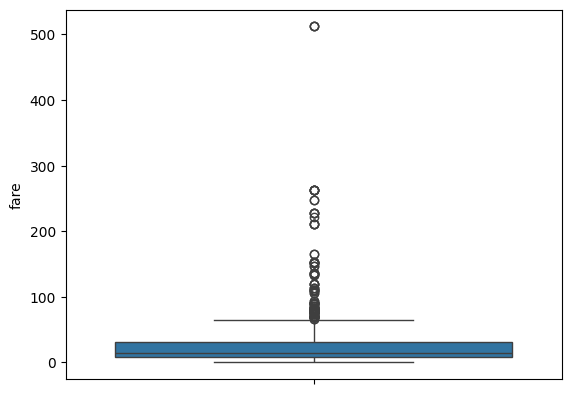

In [96]:
sns.boxplot(data = df_linear, y = 'fare')

In [97]:
df_linear['fare'].min()

np.float64(0.0)

In [98]:
df_linear = df_linear[(df_linear['fare'] > 8 & (df_linear['fare'] < 35) )]

In [99]:
x = df_linear[['age']]
y = df_linear['fare']

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# To call model
model = LinearRegression()

# Train the model 
model.fit(x,y)

# Prediction
model.predict([[80]])

c:\Users\MARWAT LAPTOP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([50.88987704])

In [105]:
# Model evaluation with metrices
# r2
# mean squared error
# MAE
# RMSE

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.8)

# Model
model = LinearRegression()

# Train model
model.fit(x_train, y_train)

# Predication
predicaton = model.predict(x_test)

<Axes: xlabel='fare'>

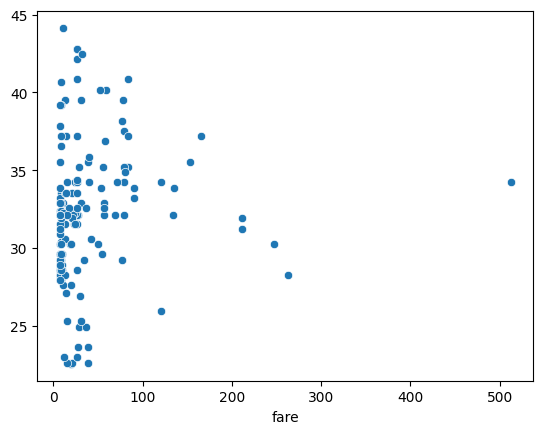

In [106]:
# Compare through plot
sns.scatterplot(x = y_test, y = predicaton)

In [110]:
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score,root_mean_squared_error

MAE = mean_absolute_error(y_true=y_test, y_pred=predicaton)
MSE = mean_squared_error(y_true=y_test, y_pred=predicaton)
RMSE = root_mean_squared_error(y_true=y_test, y_pred=predicaton)
R2 =   r2_score(y_true=y_test, y_pred=predicaton)

print("MAE:",MAE)
print("MSE:",MSE)
print("RMSE:",RMSE)
print("R_squared:",R2)

MAE: 29.737600853774833
MSE: 3116.725354367863
RMSE: 55.82763969905823
R_squared: 0.007485544236149444


In [111]:
import numpy as np
RMSE = np.sqrt(MSE)
RMSE

np.float64(55.82763969905823)